# 04 — Final selection, costs and statistical robustness

This notebook inspects the locked-test equity curves, transaction-cost sensitivity, bootstrap intervals and multiple-comparison-adjusted Diebold–Mariano tests.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / 'data').exists(): ROOT = (ROOT / '..').resolve()
processed = ROOT / 'data/processed'
summary = json.loads((ROOT / 'reports/experiment_summary.json').read_text())
display(pd.DataFrame(summary['assets']).T[['winner', 'validation_score']])
gold_equity = pd.read_csv(processed / 'gold_test_equity.csv', index_col=0, parse_dates=True)
silver_equity = pd.read_csv(processed / 'silver_test_equity.csv', index_col=0, parse_dates=True)
gold_costs = pd.read_csv(processed / 'gold_cost_sensitivity.csv')
silver_costs = pd.read_csv(processed / 'silver_cost_sensitivity.csv')

,winner,validation_score
gold,extra_trees,0.618012
silver,directional_logistic,1.451147


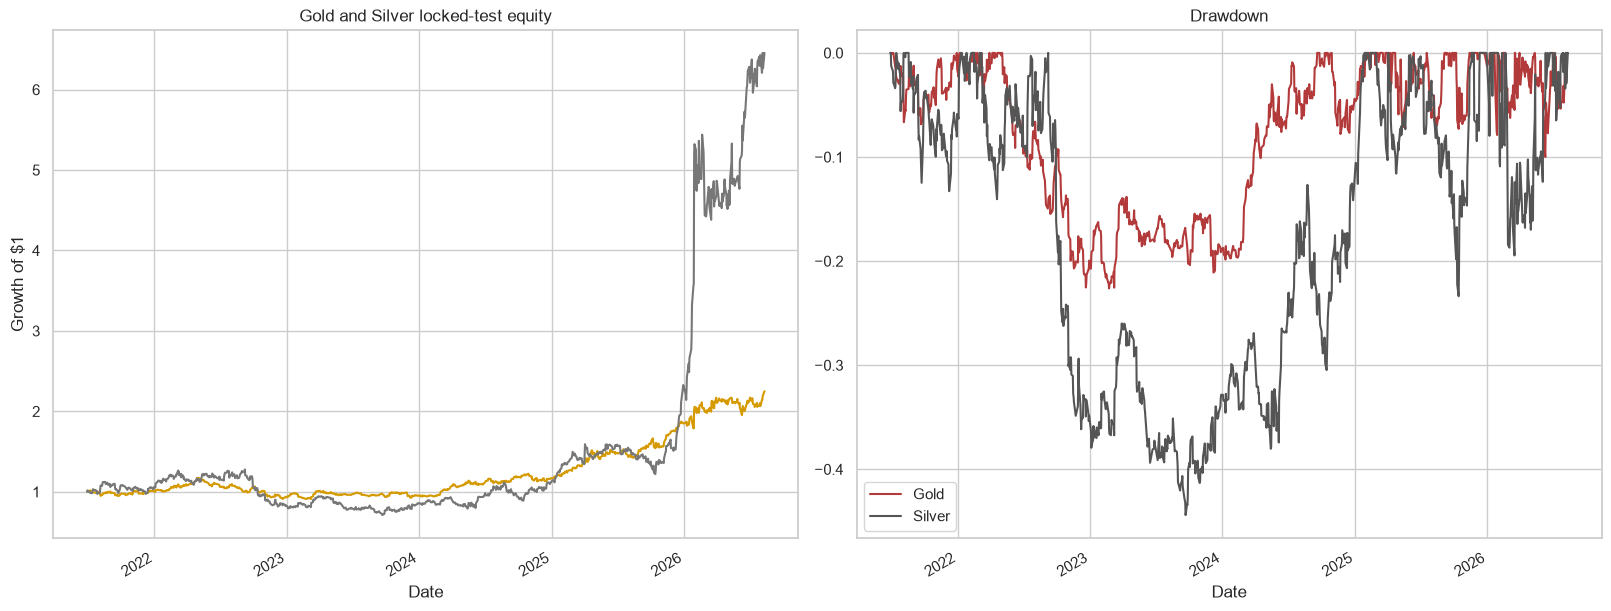

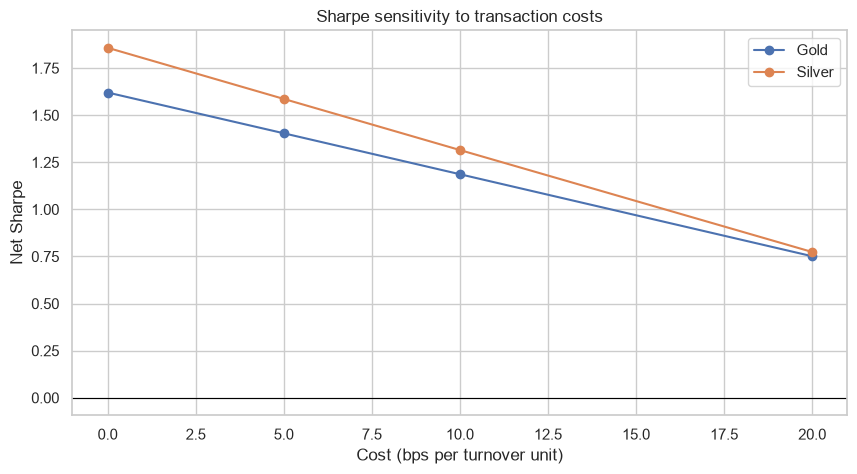

In [2]:
sns.set_theme(style='whitegrid', context='notebook')
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
gold_equity['equity'].plot(ax=axes[0], color='#d49a00', title='Gold locked-test equity')
silver_equity['equity'].plot(ax=axes[0], color='#777777', title='Gold and Silver locked-test equity')
axes[0].set_ylabel('Growth of $1')
gold_equity['drawdown'].plot(ax=axes[1], color='#b33a3a', label='Gold')
silver_equity['drawdown'].plot(ax=axes[1], color='#555555', label='Silver')
axes[1].set_title('Drawdown')
axes[1].legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gold_costs['transaction_cost_bps'], gold_costs['sharpe'], marker='o', label='Gold')
ax.plot(silver_costs['transaction_cost_bps'], silver_costs['sharpe'], marker='o', label='Silver')
ax.axhline(0, color='black', linewidth=0.8)
ax.set(title='Sharpe sensitivity to transaction costs', xlabel='Cost (bps per turnover unit)', ylabel='Net Sharpe')
ax.legend()
plt.show()

GOLD


,competitor,dm_statistic,p_value_holm,significant_5pct_holm,sharpe_difference,difference_ci_low,difference_ci_high
0,zero,-1.766013,4.643623e-01,False,1.186625,0.255773,2.066621
1,tree_blend,0.000000,1.000000e+00,False,0.000000,0.000000,0.000000
2,xgboost,-0.229834,1.000000e+00,False,0.581931,-0.241633,1.393805
3,elasticnet,-1.368204,8.562404e-01,False,0.062396,-0.969032,1.098668
4,hist_gradient_boosting,-1.299057,8.562404e-01,False,0.829232,-0.184385,1.892896
5,ridge,0.061295,1.000000e+00,False,1.011908,-0.228156,2.295955
6,directional_logistic,-9.148172,5.790496e-19,True,1.174662,-0.157573,2.384462
7,moving_average,-3.852412,8.187193e-04,True,0.824764,-0.356340,1.952774
8,patch_tst,-18.381738,2.207754e-74,True,2.376642,1.115690,3.765964
9,time_mixer,-5.343108,7.309310e-07,True,1.573921,0.124802,3.106143


SILVER


,competitor,dm_statistic,p_value_holm,significant_5pct_holm,sharpe_difference,difference_ci_low,difference_ci_high
0,zero,17.711539,2.049633e-69,True,1.315027,0.351874,2.128178
1,xgboost,17.734835,1.665611e-69,True,1.047332,-0.041883,2.324333
2,hist_gradient_boosting,17.755424,1.408371e-69,True,0.814379,-0.415599,2.096109
3,elasticnet,17.739385,1.665611e-69,True,0.569114,-0.452030,1.657470
4,ridge,17.812748,6.753347e-70,True,0.477959,-0.322189,1.306684
5,tree_blend,17.763475,1.395747e-69,True,0.685172,-0.545440,1.973125
6,patch_tst,-15.192835,1.183442e-51,True,1.643031,0.430617,3.083153
7,moving_average,17.465806,1.304951e-67,True,0.951522,-0.359149,2.053676
8,extra_trees,17.767192,1.395747e-69,True,0.391366,-0.799690,1.594074
9,time_mixer,-0.421847,9.883857e-01,False,1.222560,0.088291,2.578488


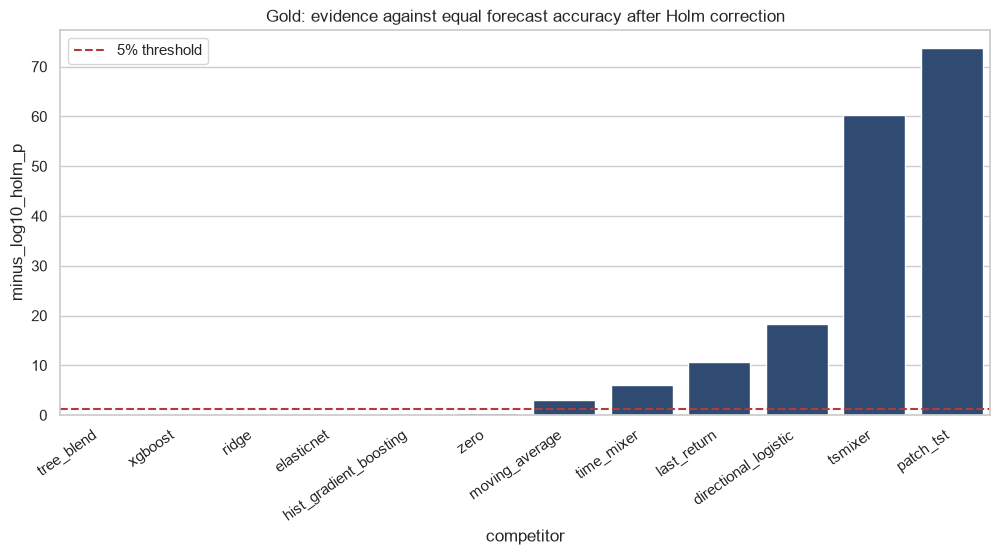

In [3]:
for asset in ['gold', 'silver']:
    tests = pd.read_csv(processed / f'{asset}_statistical_tests.csv')
    print(asset.upper())
    display(tests[['competitor', 'dm_statistic', 'p_value_holm', 'significant_5pct_holm', 'sharpe_difference', 'difference_ci_low', 'difference_ci_high']])

gold_tests = pd.read_csv(processed / 'gold_statistical_tests.csv')
plot_tests = gold_tests.copy()
plot_tests['minus_log10_holm_p'] = (-plot_tests['p_value_holm'].clip(lower=1e-300).apply(lambda x: __import__('math').log10(x)))
plt.figure(figsize=(12, 5))
sns.barplot(data=plot_tests.sort_values('minus_log10_holm_p'), x='competitor', y='minus_log10_holm_p', color='#244a7c')
plt.axhline(-__import__('math').log10(0.05), color='#b33a3a', linestyle='--', label='5% threshold')
plt.xticks(rotation=35, ha='right')
plt.title('Gold: evidence against equal forecast accuracy after Holm correction')
plt.legend()
plt.show()

,origin_mean_sharpe,origin_positive_fraction,reality_check_p
gold,0.695131,0.666667,0.089910
silver,0.219762,0.666667,0.020979


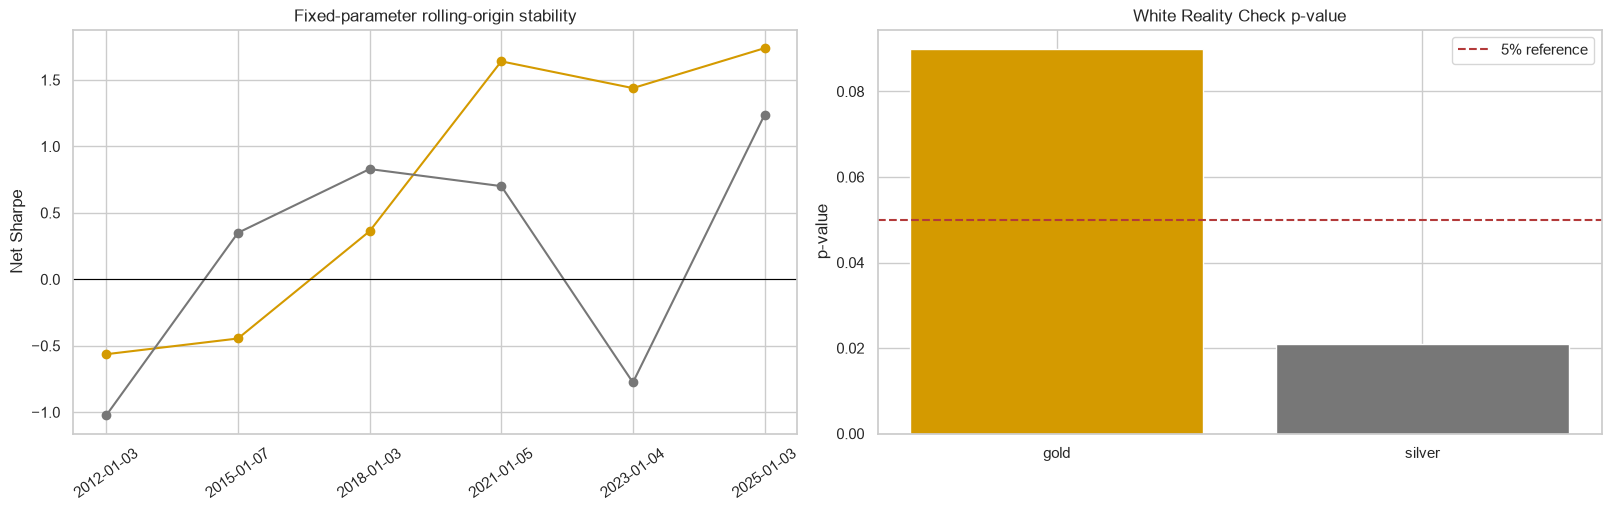

In [4]:
robustness = {}
for asset in ['gold', 'silver']:
    origin = pd.read_csv(processed / f'{asset}_origin_stability.csv')
    reality = pd.read_csv(processed / f'{asset}_reality_check.csv')
    robustness[asset] = {'origin_mean_sharpe': origin['sharpe'].mean(), 'origin_positive_fraction': (origin['sharpe'] > 0).mean(), 'reality_check_p': reality.loc[0, 'p_value_max_sharpe']}
display(pd.DataFrame(robustness).T)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
for asset, color in [('gold', '#d49a00'), ('silver', '#777777')]:
    origin = pd.read_csv(processed / f'{asset}_origin_stability.csv')
    axes[0].plot(origin['origin'], origin['sharpe'], marker='o', label=asset.title(), color=color)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set(title='Fixed-parameter rolling-origin stability', ylabel='Net Sharpe')
axes[0].tick_params(axis='x', rotation=35)
reality_plot = pd.DataFrame(robustness).T
axes[1].bar(reality_plot.index, reality_plot['reality_check_p'], color=['#d49a00', '#777777'])
axes[1].axhline(0.05, color='#b33a3a', linestyle='--', label='5% reference')
axes[1].set(title='White Reality Check p-value', ylabel='p-value')
axes[1].legend()
plt.show()

In [5]:
global_stats_path = processed / 'global_model_statistical_tests.csv'
if global_stats_path.exists():
    print('Shared global model versus local winner')
    display(pd.read_csv(global_stats_path)[['asset', 'local_winner', 'local_sharpe', 'global_sharpe', 'dm_statistic', 'p_value_two_sided', 'sharpe_difference']].round(4))


Shared global model versus local winner


,asset,local_winner,local_sharpe,global_sharpe,dm_statistic,p_value_two_sided,sharpe_difference
0,gold,extra_trees,1.1866,-0.7653,-2.3800,0.0173,1.9519
1,silver,directional_logistic,1.2423,0.6192,17.4509,0.0000,0.6231


**How to read the plots.** Equity curves compound the signed next-day return after transaction costs; drawdown is the distance below the prior equity high. Cost sensitivity tests implementation friction, while the Reality Check p-value asks whether the best of many candidates could arise from selection noise. Negative rolling-origin Sharpes expose regime fragility.